<a href="https://colab.research.google.com/github/Mithu06-dev/AIML-Learning-/blob/main/Hierarchical%20Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset loaded successfully
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

        InvoiceDate  UnitPrice  CustomerID         Country  
0  01-12-2010 08:26       2.55     17850.0  United Kingdom  
1  01-12-2010 08:26       3.39     17850.0  United Kingdom  
2  01-12-2010 08:26       2.75     17850.0  United Kingdom  
3  01-12-2010 08:26       3.39     17850.0  United Kingdom  
4  01-12-2010 08:26       3.39     17850.0  United Kingdom  
(185358, 8)

RFM DATA:
            Recency  Frequency  Monetary
CustomerID                              
12346.0         114          1  77183.60
12347.0          35        

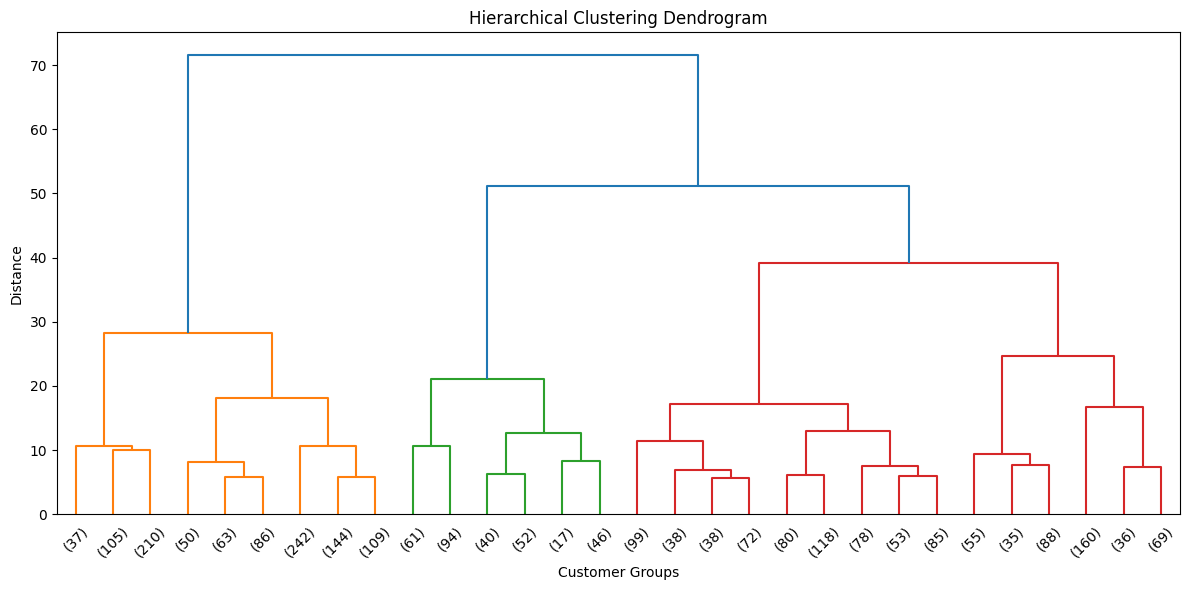


Hierarchical Clustering Silhouette Score: 0.3102

Customer Clusters:
            Recency  Frequency  Monetary  Cluster
CustomerID                                       
12347.0          35          3   1823.43        2
12348.0          37          3   1487.24        3
12350.0          98          1    334.40        0
12352.0          50          5   1561.81        3
12354.0          20          1   1079.40        0
12355.0           2          1    459.40        1
12356.0          34          2   2753.08        2
12359.0          93          2   2386.41        3
12361.0          75          1    189.90        0
12362.0          14          2    974.34        3
12363.0          30          1    299.10        1
12365.0          79          2    641.38        3
12370.0          62          3   2806.41        2
12372.0           1          2    914.92        1
12373.0          99          1    364.60        0
12377.0         103          2   1628.12        3
12383.0          26          4

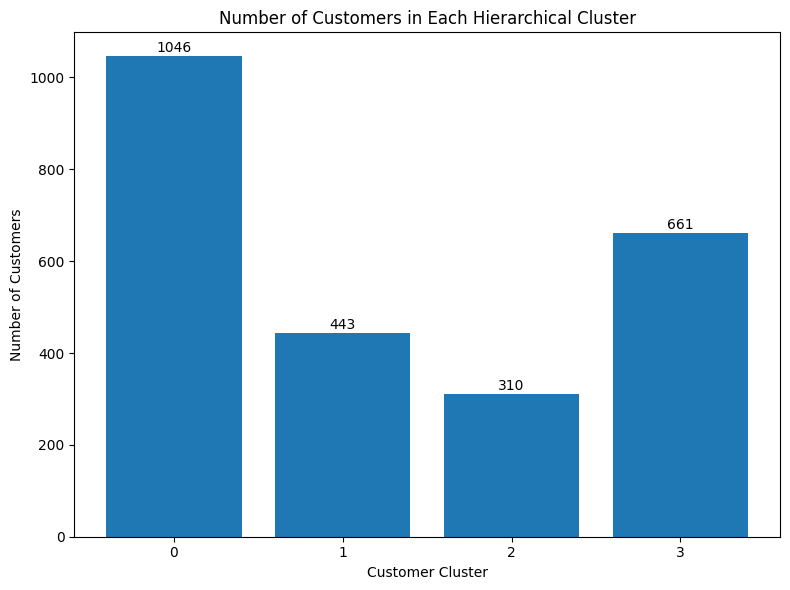

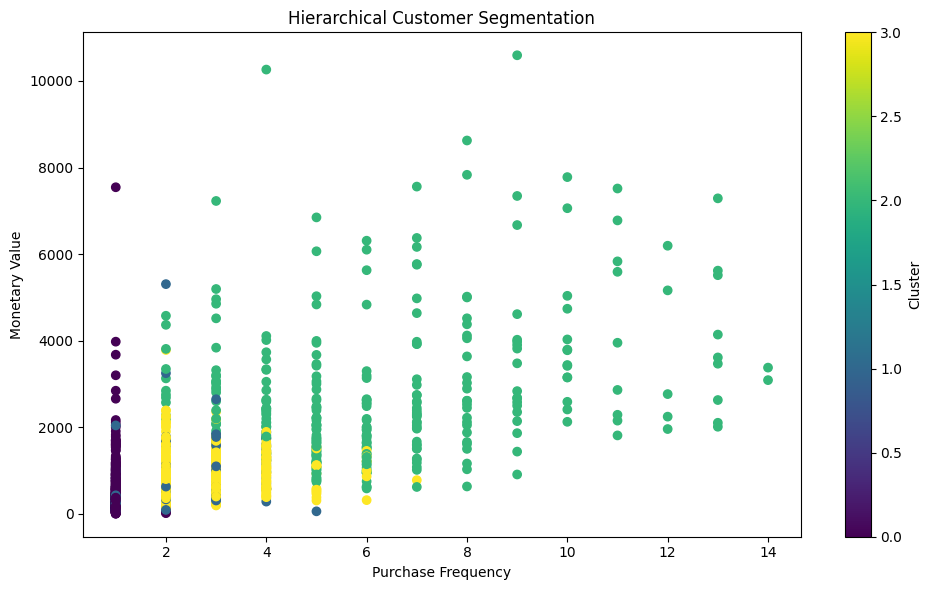

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage


# =========================================================
# 1. LOAD DATASET
# =========================================================

df = pd.read_csv("/content/OnlineRetail.csv", encoding='latin1')

print("Dataset loaded successfully")
print(df.head())
print(df.shape)


# =========================================================
# 2. DATA CLEANING
# =========================================================

# Remove rows without CustomerID
df = df.dropna(subset=["CustomerID"])

# Remove cancelled invoices
df = df[
    ~df["InvoiceNo"].astype(str).str.startswith("C")
]

# Remove negative/zero quantity
df = df[df["Quantity"] > 0]

# Remove zero/negative prices
df = df[df["UnitPrice"] > 0]


# =========================================================
# 3. CREATE TOTAL PRICE
# =========================================================

df["TotalPrice"] = (
    df["Quantity"] * df["UnitPrice"]
)


# =========================================================
# 4. CONVERT INVOICE DATE
# =========================================================

df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    format="%d-%m-%Y %H:%M"
)


# =========================================================
# 5. CREATE REFERENCE DATE
# =========================================================

reference_date = (
    df["InvoiceDate"].max()
    + pd.Timedelta(days=1)
)


# =========================================================
# 6. CREATE RFM FEATURES
# =========================================================

rfm = df.groupby("CustomerID").agg({

    "InvoiceDate":
        lambda x:
        (reference_date - x.max()).days,

    "InvoiceNo":
        "nunique",

    "TotalPrice":
        "sum"
})


# Rename columns

rfm.columns = [
    "Recency",
    "Frequency",
    "Monetary"
]


print("\nRFM DATA:")
print(rfm.head())


# =========================================================
# 7. REMOVE EXTREME VALUES
# =========================================================

rfm = rfm[
    (rfm["Recency"] < rfm["Recency"].quantile(0.99)) &
    (rfm["Frequency"] < rfm["Frequency"].quantile(0.99)) &
    (rfm["Monetary"] < rfm["Monetary"].quantile(0.99))
]


# =========================================================
# 8. LOG TRANSFORMATION
# =========================================================

rfm_log = np.log1p(rfm)


# =========================================================
# 9. STANDARDIZATION
# =========================================================

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm_log
)


# =========================================================
# 10. DENDROGRAM
# =========================================================

plt.figure(figsize=(12, 6))

linked = linkage(
    rfm_scaled,
    method="ward"
)

dendrogram(
    linked,
    truncate_mode="lastp",
    p=30
)

plt.title(
    "Hierarchical Clustering Dendrogram"
)

plt.xlabel("Customer Groups")

plt.ylabel("Distance")

plt.tight_layout()

plt.show()


# =========================================================
# 11. HIERARCHICAL CLUSTERING
# =========================================================

model = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"
)

clusters = model.fit_predict(
    rfm_scaled
)


# =========================================================
# 12. ADD CLUSTER TO RFM DATA
# =========================================================

rfm["Cluster"] = clusters


# =========================================================
# 13. SILHOUETTE SCORE
# =========================================================

score = silhouette_score(
    rfm_scaled,
    clusters
)

print(
    "\nHierarchical Clustering Silhouette Score:",
    round(score, 4)
)


# =========================================================
# 14. DISPLAY CUSTOMER CLUSTERS
# =========================================================

print("\nCustomer Clusters:")

print(
    rfm.head(20)
)


# =========================================================
# 15. CLUSTER SUMMARY
# =========================================================

cluster_summary = rfm.groupby(
    "Cluster"
)[
    ["Recency", "Frequency", "Monetary"]
].mean()


print("\nCluster Summary:")

print(
    cluster_summary
)


# =========================================================
# 16. CUSTOMER COUNT PER CLUSTER
# =========================================================

cluster_counts = rfm[
    "Cluster"
].value_counts().sort_index()


plt.figure(figsize=(8, 6))

plt.bar(
    cluster_counts.index.astype(str),
    cluster_counts.values
)

plt.xlabel("Customer Cluster")

plt.ylabel("Number of Customers")

plt.title(
    "Number of Customers in Each Hierarchical Cluster"
)

for i, value in enumerate(
    cluster_counts.values
):

    plt.text(
        i,
        value + 10,
        str(value),
        ha="center"
    )

plt.tight_layout()

plt.show()


# =========================================================
# 17. RFM CLUSTER VISUALIZATION
# =========================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    rfm["Frequency"],
    rfm["Monetary"],
    c=rfm["Cluster"]
)

plt.xlabel(
    "Purchase Frequency"
)

plt.ylabel(
    "Monetary Value"
)

plt.title(
    "Hierarchical Customer Segmentation"
)

plt.colorbar(
    label="Cluster"
)

plt.tight_layout()

plt.show()